# Random Forest Hyperparameter Tuning — Audio Features

This notebook tunes the random-forest baseline over the audio-feature split, exploring tree counts, depths, leaf sizes, and feature subsampling while monitoring loss/accuracy/AUC per configuration.

In [1]:
from pathlib import Path
import logging
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, roc_auc_score
from tqdm.auto import tqdm

from ml.data import (
    AUDIO_FEATURES,
    RANK_COLUMN,
    create_classification_splits,
    load_classification_dataframe,
)
from ml.models import build_random_forest
from ml.train import train_random_forest_incremental, plot_training_history


/Users/hallaei/miniconda3/envs/aml_cwl/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s')

In [3]:
DATA_PATH = Path('data/datasets/Spotify_Dataset_V3.csv')
TOP_K = 10
FEATURE_SET_NAME = 'Audio Features'
HOLDOUT_FRACTION = 0.4
DEV_SHARE = 0.5
RANDOM_STATE = 51
EPOCHS_PER_CONFIG = 10

feature_cols = AUDIO_FEATURES


In [4]:
classification_df, target_col = load_classification_dataframe(
    DATA_PATH, feature_cols, RANK_COLUMN, TOP_K, FEATURE_SET_NAME
)
train_df, dev_df, test_df = create_classification_splits(
    classification_df,
    target_col,
    HOLDOUT_FRACTION,
    DEV_SHARE,
    RANDOM_STATE,
)
print(
    f'Train={len(train_df)} Dev={len(dev_df)} Test={len(test_df)} | '
    f'Pos rates -> Train {train_df[target_col].mean():.2%}, '
    f'Dev {dev_df[target_col].mean():.2%}, Test {test_df[target_col].mean():.2%}'
)


2025-11-19 23:39:40,778 [INFO] Loading dataset from data/datasets/Spotify_Dataset_V3.csv
2025-11-19 23:39:43,576 [INFO] Prepared dataframe with 651936 songs (positive rate 4.82%).
2025-11-19 23:39:43,592 [INFO] Creating splits with holdout_fraction=0.40 and dev_share=0.50


Engineering Audio Features...


2025-11-19 23:39:43,771 [INFO] Split sizes -> train=395328, dev=126410, test=130198
2025-11-19 23:39:43,783 [INFO] Train split positive rate: 4.73%
2025-11-19 23:39:43,809 [INFO] Dev split positive rate: 4.81%
2025-11-19 23:39:43,840 [INFO] Test split positive rate: 5.08%


Train=395328 Dev=126410 Test=130198 | Pos rates -> Train 4.73%, Dev 4.81%, Test 5.08%


In [5]:
dataset_splits = {
    'Train': (train_df[feature_cols], train_df[target_col]),
    'Dev': (dev_df[feature_cols], dev_df[target_col]),
    'Test': (test_df[feature_cols], test_df[target_col]),
}
classes = sorted(train_df[target_col].unique())


## Hyperparameter grid

In [6]:
n_estimators_options = [200, 400, 600]
max_depth_options = [None, 20, 40]
min_samples_leaf_options = [1, 2, 4]
max_features_options = ['sqrt', 'log2', 0.5]
bootstrap_options = [True, False]

search_space = list(product(
    n_estimators_options,
    max_depth_options,
    min_samples_leaf_options,
    max_features_options,
    bootstrap_options,
))
len(search_space)


162

## Helper functions

In [7]:
def build_forest(random_state, config):
    n_estimators, max_depth, min_samples_leaf, max_features, bootstrap = config
    model = build_random_forest(
        random_state=random_state,
        n_estimators=n_estimators,
        max_depth=max_depth,
    )
    model.set_params(
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        bootstrap=bootstrap,
    )
    return model


def summarize_dev(model, dev_data):
    X_dev, y_dev = dev_data
    y_pred = model.predict(X_dev)
    dev_acc = accuracy_score(y_dev, y_pred)
    scores = model.predict_proba(X_dev)[:, 1]
    dev_auc = roc_auc_score(y_dev, scores)
    return dev_acc, dev_auc


## Run sweep

In [8]:
results = []
histories = {}
progress = tqdm(search_space, desc='RandomForest configs')
for config in progress:
    config_name = (
        f'n_est={config[0]} depth={config[1]} leaf={config[2]} '
        f'max_feat={config[3]} bootstrap={config[4]}'
    )
    progress.set_postfix_str(config_name)
    model = build_forest(RANDOM_STATE, config)
    trained_model, history_df = train_random_forest_incremental(
        model,
        dataset_splits['Train'],
        dataset_splits['Dev'],
        epochs=EPOCHS_PER_CONFIG,
        classes=classes,
    )
    dev_acc, dev_auc = summarize_dev(trained_model, dataset_splits['Dev'])
    best_val_loss = history_df['val_loss'].min()
    results.append({
        'n_estimators': config[0],
        'max_depth': config[1],
        'min_samples_leaf': config[2],
        'max_features': config[3],
        'bootstrap': config[4],
        'best_val_loss': best_val_loss,
        'dev_accuracy': dev_acc,
        'dev_auc': dev_auc,
        'stages': len(history_df),
    })
    histories[config_name] = history_df

results_df = pd.DataFrame(results).sort_values('best_val_loss').reset_index(drop=True)
results_df.head()


RandomForest configs:   0%|          | 0/162 [00:00<?, ?it/s, n_est=200 depth=None leaf=1 max_feat=sqrt bootstrap=True]/Users/hallaei/miniconda3/envs/aml_cwl/lib/python3.9/site-packages/sklearn/ensemble/_forest.py:861: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use compute_class_weight ("balanced", classes, y). In place of y you can use a large enough sample of the full training set target to properly estimate the class frequency distributions. Pass the resulting weights as the class_weight parameter.
  warn(
2025-11-19 23:39:44,793 [INFO] Forest stage 1/10 (trees=1) - loss: 0.3245 - val_loss: 2.0764 - accuracy: 0.8814 - val_accuracy: 0.8836 - auc: 0.9424 - val_auc: 0.6262
/Users/hallaei/miniconda3/envs/aml_cwl/lib/python3.9/site-packages/sklearn/ensemble/_forest.py:861: UserWarning: class_weight presets "balanced" or "balanced_subsample" ar

,n_estimators,max_depth,min_samples_leaf,max_features,bootstrap,best_val_loss,dev_accuracy,dev_auc,stages
0,600,20.0,1,sqrt,True,0.278923,0.926003,0.659268,10
1,600,20.0,1,log2,True,0.278923,0.926003,0.659268,10
2,200,20.0,1,log2,True,0.278923,0.923748,0.668750,10
3,200,20.0,1,sqrt,True,0.278923,0.923748,0.668750,10
4,400,20.0,1,sqrt,True,0.280284,0.926003,0.658609,10


In [11]:
# save results_df to csv
results_df.to_csv('rf_hyperparameter_search_results.csv', index=False)

## Summary statistics

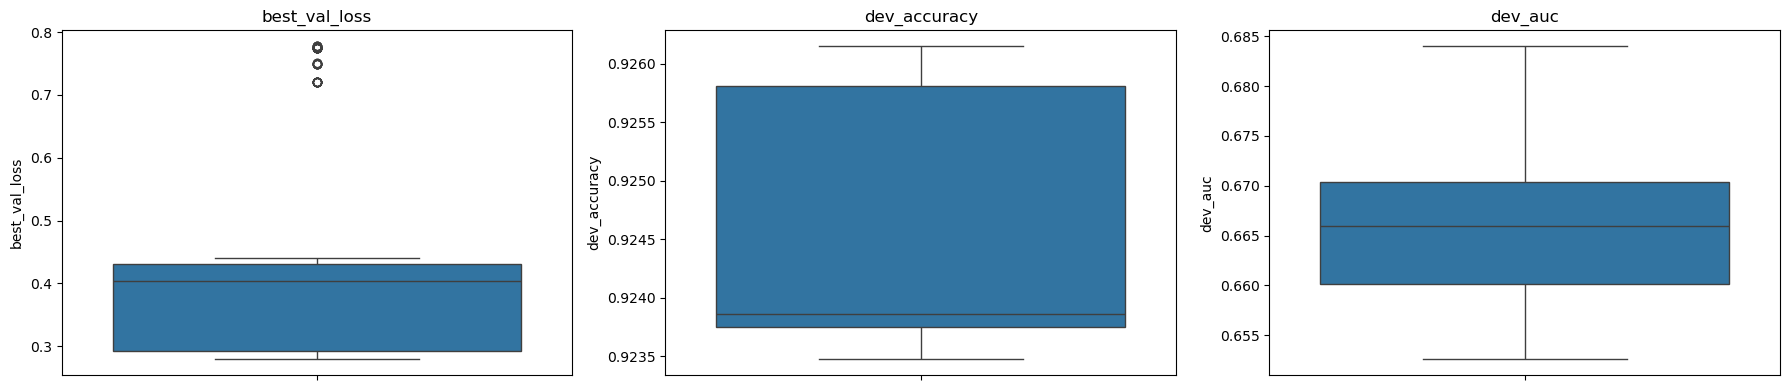

,n_estimators,max_depth,min_samples_leaf,max_features,bootstrap,best_val_loss,dev_accuracy,dev_auc
0,600,20.0,1,sqrt,True,0.278923,0.926003,0.659268
1,600,20.0,1,log2,True,0.278923,0.926003,0.659268
2,200,20.0,1,log2,True,0.278923,0.923748,0.668750
3,200,20.0,1,sqrt,True,0.278923,0.923748,0.668750
4,400,20.0,1,sqrt,True,0.280284,0.926003,0.658609
5,400,20.0,1,log2,True,0.280284,0.926003,0.658609
6,400,20.0,2,log2,True,0.285571,0.923843,0.654869
7,400,20.0,2,sqrt,True,0.285571,0.923843,0.654869
8,600,20.0,2,sqrt,True,0.285571,0.923843,0.653376
9,600,20.0,2,log2,True,0.285571,0.923843,0.653376


In [9]:
metrics = ['best_val_loss', 'dev_accuracy', 'dev_auc']
fig, axes = plt.subplots(1, len(metrics), figsize=(6 * len(metrics), 4))
for ax, metric in zip(axes, metrics):
    sns.boxplot(data=results_df, y=metric, ax=ax)
    ax.set_title(metric)
plt.tight_layout()
plt.show()

results_df[['n_estimators', 'max_depth', 'min_samples_leaf', 'max_features', 'bootstrap', 'best_val_loss', 'dev_accuracy', 'dev_auc']].head(10)


## Hyperparameter effects

TypeError: 'value' must be an instance of str or bytes, not a float

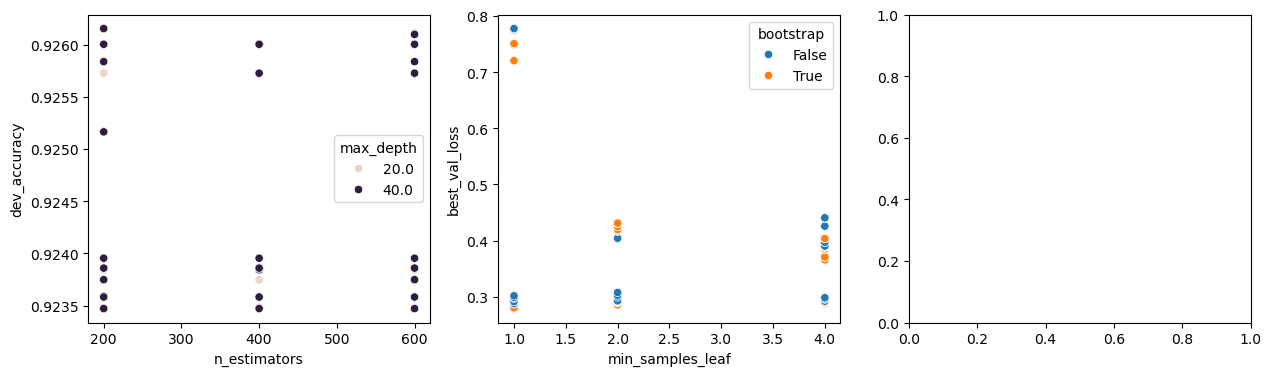

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.scatterplot(data=results_df, x='n_estimators', y='dev_accuracy', hue='max_depth', ax=axes[0])
sns.scatterplot(data=results_df, x='min_samples_leaf', y='best_val_loss', hue='bootstrap', ax=axes[1])
sns.scatterplot(data=results_df, x='max_features', y='dev_auc', hue='n_estimators', ax=axes[2])
for ax in axes:
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## Inspect top runs

In [ ]:
top_runs = results_df.head(3)
for _, row in top_runs.iterrows():
    key = (
        f"n_est={row['n_estimators']} depth={row['max_depth']} leaf={row['min_samples_leaf']} "
        f"max_feat={row['max_features']} bootstrap={row['bootstrap']}"
    )
    fig = plot_training_history(histories[key], title=key)
    plt.show()
